# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 2
## Due date: <u> 23:59, Sunday the 10th May, 2026 </u>




## Submission guidline:

* Answer the exercise questions in this Python notebook itself.
* One submission per group by the due date on LMS. Export your notebook file (.ipynb) as a PDF file. You should submit both ipynb and pdf files.
* For questions involving mathematical derivation, you can either choose to type your solutions using Markdown (Latex), or attach a photo of your hand-written solution in the file.

<br>

## Grading:

## Exercise 2 self grading due date: <u> 23:59, Monday the 18th May, 2026 </u>
### Option 1:
*  By default, you will grade your homeworks with the solution provided by us
* Submission of graded homeworks: solutions will be posted on LMS on 11th May with a grading guideline. You have one week to grade your homeworks. Submit your graded homework (as a PDF file) before 23:59, 18th May. You should note down all marks for individual subquestions, and include your total mark on page 1 of your PDF file. An example will be provided later.
* If you do not submit a graded version by 23:59, 18th May, your homework will be graded by demonstrators.

### Option 2:
* If you wish to have your homeworks graded by demonstrators, please send an email to Muhan (muhan.guan.1@unimelb.edu.au) by the homework due date, and you do not need to submit a graded version. If you choose this path and submit a graded version, we will still mark your homework instead of using your self-graded results.





## Submission guideline:

* One submission per group by the due date on LMS.
* Answer the exercise questions in this Python notebook itself.
* Export your notebook file (.ipynb) as a PDF file, on which we give marks and comments. This means that each group should submit two versions of the exercise report (.ipynb file and PDF).
* Demonstrators will conduct a brief oral assessment for selected groups in subsequent workshop. Details will be announced on LMS.
* Regarding the use of LLM and other generative AI tools: refer to information in the introductory slides.





## Declaration:

I used **Claude Code** as a GenAI tool in this assignment for the following purposes:

- Discussing mathematical concepts and python library usage for implementation
- Verifying approaches to solving each question
- Formatting additional study notes [[Additional_Notes_Ex_2.md]]

and I take full accountability for my own submission works.

## Question 1 (Bayesian infrence, MLE and MAP) (Mark:  5 + 7 + 2 + 6 = 20 points)
In this question, we'll explore Bayesian infrence, MLE and MAP.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.rcParams["animation.html"] = "jshtml"
from scipy.stats import bernoulli, beta

**A lucky find**

On the way to class, you discover an unusual coin on the ground.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/68/1_2_penny_Middlesex_DukeYork_1795_1ar85_%288737903267%29.jpg" alt="Coin" width="350"/>

As a dedicated student in SOML, you're interested in determining whether the coin is _biased_.
More specifically, you want to estimate the probability $\theta$ that the coin will land heads-up when you toss it. If $\theta \approx \frac{1}{2}$ then we say that the coin is _unbiased_ (or fair).

You can use the function below to simulate a coin toss: it returns `1` for heads and `0` for tails.

In [ ]:
def toss_coin():
    if bernoulli.rvs(p = (int.from_bytes("coin".encode(), 'little') % 10000)/10000):
        return 1
    return 0
# "coin".encode(): Converts the string into a sequence of bytes based on ASCII values (c=99, o=111, i=105, n=110).
# int.from_bytes(..., 'little'): Takes those bytes and calculates a single large integer using little-endian byte order. The math evaluates to: 99 + (111 * 256) + (105 * 256^2) + (110 * 256^3) = 1852403555.
# So the probability of getting heads is 0.3555.
# `bernoulli.rvs(p=0.3555)` simulates a coin toss with such probability.

In [ ]:
(int.from_bytes("coin".encode(), 'little') % 10000)/10000

In [ ]:
x1 = toss_coin()
print(x1)

**Prior belief**

Before you even toss the coin, you notice that the heads side appears to have more mass.
Thus, your _prior belief_ is that $\theta$ is slightly biased away from $\frac{1}{2}$ towards 0—i.e. you expect tails are more likely.

To quantify this prior belief, we assume that the prior distribution for $\theta$ is $\mathrm{Beta}(a,b)$, for some choice of the hyperparameters $a, b > 0$.
(See [link](https://en.wikipedia.org/wiki/Beta_distribution) for info about the **Beta distribution**.)
The prior probability density function for $\theta$ is therefore given by:

$$ p(\theta) = \frac{1}{B(a,b)} \theta^{a-1} (1 - \theta)^{b-1} $$

where $B(a,b)$ is a special function called the [_Beta function_](https://en.wikipedia.org/wiki/Beta_function). (It acts as a normalising constant to ensure the density integrates to 1.)

Select appropriate values for $a$ and $b$ by looking at the plot of $p(\theta)$ below.

**Notes:**

For a Beta distribution $\theta \sim Beta(a,b)$, the probability density function reaches its maximum (also known as the [mode](https://en.wikipedia.org/wiki/Mode_(statistics))) at the value:
$$
mode = \frac{a - 1}{a + b - 2}
$$

This formula applies when $a > 1$ and $b > 1$. Since you want the maximum to occur at $0.3555$, we can set up the following equation:
$$
\frac{a - 1}{a + b - 2} = 0.3555 = \frac{711}{2000}
$$

For a certain $a$, $b$ can be solved by
$$
b = \frac{a(1-p)+2p-1}{p} = \frac{a-1}{p} - a + 2
$$

Some possible pairs:
$$
(a,b) = (712, 1290), (2, 2000/711\approx2.8129), (10, 17.32)
$$

In [ ]:
p = 0.3555
a = 10 # fill in
b = (a-1)/p - a + 2 # fill in
theta = np.linspace(0, 1, 1001)
plt.plot(theta, beta.pdf(theta, a, b))
plt.title('Prior distribution')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p(\theta)$')
plt.show()

**Posterior updates:** Now toss the coin once and denote the outcome by $x_1$.

In [ ]:
x1 = toss_coin()
print(x1)

We can update our belief about $\theta$, based on this new evidence $x_1$.
To do this we apply Bayes' rule to compute the posterior for $\theta$:

$$ p(\theta | x_1) = \frac{p(x_1 | \theta) \, p(\theta)}{p(x_1)} \propto p(x_1 | \theta) \, p(\theta)$$

where $p(\theta)$ is the prior given above and

$$ p(x_1 | \theta) = \theta^{x_1} (1 - \theta)^{1 - x_1} $$

is the likelihood.

\[Note: We always assume the tosses are independent, otherwise the likelihood for $x_2$ would depend on $x_1$.\]
***


### Part A: Mathematical Derivation

Toss the coin a second time, denoting the outcome by $x_2$.

In [ ]:
x2 = toss_coin()
print(x2)

Again, we want to update our belief about $\theta$ based on the new information $x_2$.
We take the previous posterior $p(\theta|x_1)$ as the new prior and apply Bayes' rule:

$$ p(\theta | x_1, x_2) \propto p(x_2 | \theta) p(\theta | x_1)$$

(如此形式（需要复杂推导）何用意？意图引导可以链式展开？不如直接给出简单Bayes' rule)

***
Show that for $n$ coin tosses, the posterior is $\theta | x_1, \ldots, x_n \sim \operatorname{Beta}[n_H + a, n - n_H + b]$ where $n_H = \sum_{i = 1}^{n} x_i$ is the number of heads observed.

***

#### Solution:

**Prior:** $\theta \sim \text{Beta}(a, b)$, so

$$
p(\theta) = \frac{1}{B(a,b)} \theta^{a-1} (1 - \theta)^{b-1}
$$

**Likelihood for one toss:** $p(x_i \mid \theta) = \theta^{x_i}(1-\theta)^{1-x_i}$

Since the tosses are conditionally independent given $\theta$, the joint likelihood for $n$ tosses is:

$$
p(x_1, \ldots, x_n \mid \theta) = \prod_{i=1}^{n} \theta^{x_i}(1-\theta)^{1-x_i} = \theta^{n_H}(1-\theta)^{n - n_H}
$$

where $n_H = \sum_{i=1}^{n} x_i$ is the number of heads.

**Posterior** (by Bayes' rule, dropping constants independent of $\theta$):

$$
p(\theta \mid x_1, \ldots, x_n) \propto p(x_1, \ldots, x_n \mid \theta) \, p(\theta)
$$

$$
= \theta^{n_H}(1-\theta)^{n-n_H} \cdot \theta^{a-1}(1-\theta)^{b-1}
$$

$$
= \theta^{(n_H + a) - 1}(1-\theta)^{(n - n_H + b) - 1}
$$

This is the kernel of a Beta distribution. Since the posterior must integrate to 1, we identify:

$$
\boxed{\theta \mid x_1, \ldots, x_n \sim \text{Beta}(n_H + a, \; n - n_H + b)}
$$

**Interpretation:** Each head increments the first parameter by 1, each tail increments the second parameter by 1. The prior hyperparameters $a$ and $b$ act as "pseudo-counts" — as if we had observed $a - 1$ heads and $b - 1$ tails before any real data.

### Part B:  Mathematical Derivation for MAP estimator and MLE estimator

The posterior $\theta|x_1, \ldots, x_n$ contains all the information we know about $\theta$ after observing $n$ coin tosses.
One way of obtaining a point estimate of $\theta$ from the posterior, is to take the value with the maximum a posteriori probability (MAP):
$$
\begin{align}
    \hat{\theta}_\mathrm{MAP} &= \arg \max_{\theta} p(\theta|x_1, \ldots, x_n) \tag{1}
\end{align}
$$

In general, the MAP estimator gives a different result to the maximum likelihood estimator (MLE) for $\theta$:
$$
\begin{align}
    \hat{\theta}_\mathrm{MLE} &=\arg \max_{\theta} p(x_1, \ldots, x_n|\theta) \tag{2}
\end{align}
$$

***
 How would you derive the above results for $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$? Setup the equations for solving $\hat{\theta}_\mathrm{MAP}$ and  $\hat{\theta}_\mathrm{MLE}$ and then solve them.


#### Solution:

From Part A, the posterior is $\theta \mid x_1, \ldots, x_n \sim \text{Beta}(n_H + a, \; n - n_H + b)$, with density:

$$
p(\theta \mid x_1, \ldots, x_n) \propto \theta^{n_H + a - 1}(1-\theta)^{n - n_H + b - 1}
$$

---

**MLE Derivation:**

The log-likelihood is:

$$
\ell(\theta) = \log p(x_1, \ldots, x_n \mid \theta) = n_H \log \theta + (n - n_H) \log(1 - \theta)
$$

Taking the derivative and setting it to zero:

$$
\frac{d\ell}{d\theta} = \frac{n_H}{\theta} - \frac{n - n_H}{1 - \theta} = 0
$$

$$
n_H(1 - \theta) = (n - n_H)\theta
$$

$$
n_H = n\theta
$$

$$
\boxed{\hat{\theta}_{\text{MLE}} = \frac{n_H}{n}}
$$

---

**MAP Derivation:**

The log-posterior is:

$$
\log p(\theta \mid x_1, \ldots, x_n) = (n_H + a - 1)\log \theta + (n - n_H + b - 1)\log(1 - \theta) + \text{const}
$$

Taking the derivative and setting it to zero:

$$
\frac{d}{d\theta} \log p(\theta \mid \mathbf{x}) = \frac{n_H + a - 1}{\theta} - \frac{n - n_H + b - 1}{1 - \theta} = 0
$$

Denote $(n_H + a - 1)$ as term $A$, $(n - n_H + b - 1)$ as term $B$:

$$
\frac{A}{\theta} = \frac{B}{1-\theta}
$$

$$
\theta = \frac{A}{A+B}
$$

$$
\boxed{\hat{\theta}_{\text{MAP}} = \frac{n_H + a - 1}{n + a + b - 2}}
$$

---

**Comparison:** The MAP estimate is a weighted average between the MLE ($n_H/n$) and the prior mode ($(a-1)/(a+b-2)$). As $n \to \infty$, the data dominates and $\hat{\theta}_{\text{MAP}} \to \hat{\theta}_{\text{MLE}}$. When $a = b = 1$ (uniform prior), MAP equals MLE exactly.

- **MLE:** $\log{p(\mathbf{x} \mid \theta)}$ -- likelihood only
- **MAP:** $\log{p(\mathbf{x} \mid \theta)} + \log{p(\theta)}$ -- likelihood + prior

### Part C: Programming
Let's now toss the coin an additional 100 times (so that $n = 102$) using the given function ``toss_coin()``. After each toss, compute and record $\hat{\theta}_\mathrm{MLE}$ and $\hat{\theta}_\mathrm{MAP}$ (using the expresssion you solved from Part B). Plot both estimates as two lines on the same graph. To compute $\hat{\theta}_\mathrm{MAP}$, we set the parameters of the beta prior distribution as $a=2$ and $b=6$.

In [ ]:
# Part C: Plot MLE and MAP estimates over 102 coin tosses
a, b = 2, 6

# First two tosses already done
tosses = [x1, x2]
# Toss 100 more times
for _ in range(100):
    tosses.append(toss_coin())

n_values = np.arange(1, len(tosses) + 1) # `.arrange()`: array of integers from 1 to end
n_H_values = np.cumsum(tosses) # `.cumsum()`: cumulative sum of array

theta_MLE = n_H_values / n_values
theta_MAP = (n_H_values + a - 1) / (n_values + a + b - 2)

plt.figure(figsize=(10, 5))
plt.plot(n_values, theta_MLE, label=r'$\hat{\theta}_{\mathrm{MLE}}$')
plt.plot(n_values, theta_MAP, label=r'$\hat{\theta}_{\mathrm{MAP}}$')
plt.axhline(y=0.3555, color='r', linestyle='--', alpha=0.5, label=r'True $\theta = 0.3555$')
plt.xlabel('Number of tosses $n$')
plt.ylabel(r'$\hat{\theta}$')
plt.title('MLE vs MAP estimates over 102 coin tosses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Part D: Online Learning for Coin Toss Prediction

In this task, you will consider an online learning problem for predicting the outcomes of a coin toss sequence.

Assume a sequence of coin toss outcomes
$$
x_1, x_2, \dots, x_n \sim P_\theta,
$$
where $x_i \in \{0,1\}$ and $\theta$ is the probability of observing a head $(x_i=1)$. Again, the parameter $\theta$ is unkown, and you only observe samples from this distribution.

You need **predict** the outcome at each time step $i$ given seen results of previous $(i-1)$ steps.
The reward at time $i$ is defined as:
$$
r_i =
\begin{cases}
+1, & \text{correct guess} \\
-1, & \text{wrong guess}
\end{cases}
$$



1) Develop a Maximum Likelihood Estimator based strategy that maximizes the total rewards:
$$
\max \sum_{i=1}^{n} r_i.
$$

**Data Generation**：Use the function ```toss_coin``` to generate one particular sample of 1000 coin tosses.

Note: Updating $\hat \theta$ by ML estimator, predict $\hat x_i$ as $1$ if $\hat \theta\ge 0.5$, otherwise predict it as zero. Set the first prediction as $1$ before seeing any toss results.





To assess the performance of your strategy, you compare the rewards of your strategy to the case when the parameter $\theta$ is known, and the *optimal* prediction rule is used.

2) Specifically, now you know that the true parameter $\theta$ is $0.3555$. Let $r_i^*$ denote the reward at time $i$ using this optimal prediction rule.

We can define the *normalized regret* of the strategy as
$$
R_n: =  \frac{1}{n}(\sum_{i=1}^{n} r_i^* - \sum_{i=1}^n r_i)
$$

namely the difference between the optimal reward and the reward obtained by our strategy. It signifies the cost of not knowing the true parameter $\theta$.

What is the optimal prediction rule that maximizes the total *expected reward*? Calculate the normalized regret of your strategy given this particular sequence.



3) Generate sequences with various lengths (from $n=10$ to $n=1000$) using the same random seed as in the previous question. Plot $R_n$ against $n$. Comment on your observations.





**An Important Note**: This is an online prediction problem, not a batch prediction problem. Here you use this sequence with 100 tosses to design your strategy and verify your total rewards. However, the prediction must be made sequentially. To be specific, at time step $i$, you are only allowed to use the outcomes from the previous $i-1$ tosses, and you are not allowed to use the outcome of the current (and future) toss before making your prediction.

In [ ]:
# **Global Seed:** Using `np.random.seed()` provides global reproducibility.
# SciPy's statistical functions, including bernoulli.rvs, use NumPy's random number generator to produce random variates.
np.random.seed(202690088)  # fix it
sequence = [toss_coin() for _ in range(1000)]

In [ ]:
# Part D: Online Learning for Coin Toss Prediction
# ================================================

# 1) MLE-based strategy
n_total = len(sequence)  # 1000
predictions = []
rewards = []
n_H = 0

for i in range(n_total):
    # Predict based on MLE from previous tosses
    if i == 0:
        pred = 1  # first prediction before seeing any data
    else:
        theta_hat = n_H / i  # MLE from first i tosses (0-indexed: tosses 0..i-1)
        pred = 1 if theta_hat >= 0.5 else 0
    
    predictions.append(pred)
    reward = 1 if pred == sequence[i] else -1
    rewards.append(reward)
    n_H += sequence[i]  # update count after prediction

print(f'Total reward (MLE strategy): {sum(rewards)}')
print(f'Final MLE estimate: {n_H / n_total:.4f}')

# 2) Optimal prediction rule
# Since true theta = 0.3555 < 0.5, the optimal rule always predicts 0 (tails)
theta_true = 0.3555
optimal_pred = 0  # always predict tails
optimal_rewards = [1 if optimal_pred == x else -1 for x in sequence]

# Normalized regret for full sequence
R_n = (sum(optimal_rewards) - sum(rewards)) / n_total
print(f'\nOptimal total reward: {sum(optimal_rewards)}')
print(f'Normalized regret R_n (n={n_total}): {R_n:.4f}')

# 3) Plot R_n vs n for various sequence lengths
# Regenerate with the same seed for each length
n_range = np.arange(10, 1001)
regrets = []

# Pre-compute cumulative rewards for the existing sequence
cum_rewards = np.cumsum(rewards)
cum_optimal = np.cumsum(optimal_rewards)

for n in n_range:
    R = (cum_optimal[n-1] - cum_rewards[n-1]) / n
    regrets.append(R)

plt.figure(figsize=(10, 5))
plt.plot(n_range, regrets)
plt.xlabel('$n$ (number of tosses)')
plt.ylabel('Normalized regret $R_n$')
plt.title('Normalized Regret vs Number of Tosses')
plt.grid(True, alpha=0.3) # alpha: 0 for full transparency
plt.show()

Observation: At small $n$: $R_n$ is large, as $n$ increases: $R_n\to0$. Eventually $R_n$ becomes very close to $0$. This means *asymptotically*, our strategy (without the knowledge of the true parameter) will incur the same average loss as the optimal strategy.

(1 mark for correct plot, 1 mark for the correct observation)

## Question 2: K-means Clustering (Marks: 10 + 10 = 20 Points)


### Example: Clustering and Gaussian Mixtures
Unsupervised learning is all about data. We will use first the two circles dataset to practice a little bit and digest some of the fundemental concepts. Since two circles data inherently has two clusters (each circles as a cluster), we can use this as a [ground truth](https://en.wikipedia.org/wiki/Ground_truth). In most real problems, we don't have this luxury of having the ground truth at hand! This dataset can be directly available from the sklearn library, which is shown as follows.

**Note:** This two circles dataset is available from [*Scikit Learn*](https://scikit-learn.org/stable/user_guide.html). Hint: check [*cluster*](https://scikit-learn.org/stable/api/sklearn.cluster.html#), [*datasets*](https://scikit-learn.org/stable/api/sklearn.datasets.html), [*mixture*](https://scikit-learn.org/stable/api/sklearn.mixture.html#), [*utils*](https://scikit-learn.org/stable/api/sklearn.utils.html), [*decomposition*](https://scikit-learn.org/stable/api/sklearn.decomposition.html), and [*metrics*](https://scikit-learn.org/stable/api/sklearn.metrics.html).

Scikit Learn does not have its own global random state, uses the [numpy random state](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.seed.html#numpy.random.seed) instead. See the code below.

In [ ]:
from sklearn import cluster, datasets, mixture
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from sklearn import decomposition
from sklearn.mixture import GaussianMixture
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed as you did in optimisation workshop by uncommenting the line below!
np.random.seed(16543677)


# Generate concentric circles
# factor determines the distance between the inner and outer circles
X, y = noisy_moons = datasets.make_moons(n_samples=200, noise=0.1)
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html#sklearn.datasets.make_moons

# Plot data
plt.figure()
plt.scatter(X[y==0, 0], X[y==0, 1], color='black', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1')
plt.legend()
plt.show()


### Part A: K-means Clustering (10 points)
**Questions:**
1. Use sklearn's k-means clustering algorithm to divide the data given above ($X$) into two clusters. Plot the result and show the cluster centres that you found.
2. Experiment with different starting points (`init='random'`) and number of clusters, e.g. 3, 4, 5. Plot the results.
3. Write your observations and interpret them using your theoretical knowledge from lectures and books.

#### Solution

We apply sklearn's `KMeans` to the two-moons dataset. The moons are non-convex, so we expect K-means (which partitions the plane into [Voronoi cells](https://en.wikipedia.org/wiki/Voronoi_diagram) around centroids) to ***fail to recover the ground-truth classes*** — regardless of $k$ or initialization. The goal of this part is to observe that failure mode and interpret it.

In the following I use the built-in function and methods from [`skleran.cluster.KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). See "Additional_Notes_Ex_2.md" for from-scratch code that follows the K-mean algorithm learnt in the Lecture.

In [ ]:
# Q1: K-means with k=2 using sklearn defaults (k-means++ init, n_init=10)
kmeans_2 = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)
labels_2 = kmeans_2.labels_
centers_2 = kmeans_2.cluster_centers_

plt.figure(figsize=(6, 5))
plt.scatter(X[labels_2 == 0, 0], X[labels_2 == 0, 1], color='black', label='Cluster 0')
plt.scatter(X[labels_2 == 1, 0], X[labels_2 == 1, 1], color='red', label='Cluster 1')
plt.scatter(centers_2[:, 0], centers_2[:, 1], color='blue', marker='X', s=200,
            edgecolor='white', linewidth=1.5, label='Centres')
plt.title('K-means clustering on two-moons (k=2)')
plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.legend()
plt.show()


In [ ]:
# Q2: experiment with init='random' and different k
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: k=2 with three different random initializations (n_init=1 to expose variability)
for idx, seed in enumerate([1, 7, 42]):
    km = KMeans(n_clusters=2, init='random', n_init=1, random_state=seed).fit(X)
    ax = axes[0, idx]
    for c in range(2):
        ax.scatter(X[km.labels_ == c, 0], X[km.labels_ == c, 1], label=f'Cluster {c}')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               color='blue', marker='X', s=150, edgecolor='white', linewidth=1.2)
    ax.set_title(f'k=2, init=random (seed={seed}), inertia={km.inertia_:.2f}')

# Bottom row: k=3, 4, 5
for idx, k in enumerate([3, 4, 5]):
    km = KMeans(n_clusters=k, init='random', n_init=10, random_state=0).fit(X)
    ax = axes[1, idx]
    for c in range(k):
        ax.scatter(X[km.labels_ == c, 0], X[km.labels_ == c, 1], label=f'Cluster {c}')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               color='blue', marker='X', s=150, edgecolor='white', linewidth=1.2)
    ax.set_title(f'k={k}, init=random, inertia={km.inertia_:.2f}')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()


#### Q3: Observations and Interpretation

**1. Failure on non-convex shapes (k=2).**  
With $k=2$ the algorithm does *not* recover the two moons. Instead it splits the plane roughly left/right — each cluster contains the top half of one moon and the bottom half of the other. This is the geometry K-means is *forced* to produce: its decision boundary is the perpendicular bisector between two centroids, which is a straight line. Any two-class partition produced by K-means is a Voronoi tessellation, and no straight line separates the interleaved moons.

**2. Sensitivity to initialization (k=2, `init='random'`).**  
With `n_init=1` different random seeds give different final clusterings and different inertias. K-means minimises the within-cluster sum of squares, a *non-convex* objective in the centroids, so Lloyd's algorithm only guarantees convergence to a **local** minimum. `k-means++` (sklearn default) and `n_init=10` mitigate this by seeding sensibly and restarting.

**3. Increasing $k$ does not fix the structure.**  
Using $k=3,4,5$ further fragments the data into convex sub-pieces along each moon. The inertia keeps decreasing (trivially — more centres means smaller within-cluster distances), but none of the partitions align with the true two-moon structure. More clusters $\neq$ better clustering when the inductive bias is wrong.

**4. Theoretical takeaway.**  
K-means assumes clusters are **isotropic, convex, and roughly equal-sized** while Moons violate convexity.

> [!success] Punchline
> K-means returns a **Voronoi partition** around $k$ centroids. If the ground-truth clusters are not (approximately) convex and well-separated, no amount of tweaking $k$ or the initialization will recover them — we need a different model.


### Part B: GMMs as Density Estimators (10 points)
**Questions:**
1. Now use a Gaussian Mixture Model (GMM) for clustering the same two moon data. Try two clusters and plot your results. GMMs also provides you probabilities (of a sample belonging to a cluster). Print those of a few samples using [*pandas.DataFrame*](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).
2. Increase the number of components of your GMM model, e.g., 3, 4, and 5. Plot the results.
3. Use a metric to choose the number of components in a principled way. *Hint: check [BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion) or [AIC](https://en.wikipedia.org/wiki/Akaike_information_criterion)*. Plot the result of the optimal number of components and print the probabilities of some samples.
4. Write your observations and interpret them using your theoretical knowledge from lectures and books.

#### Solution

A Gaussian Mixture Model assumes the data is generated from a mixture

$$
p(x) = \sum_{k=1}^{K} \pi_k\, \mathcal{N}(x \mid \mu_k, \Sigma_k),
$$

with $\pi_k \geq 0$ and $\sum_k \pi_k = 1$. Unlike K-means, each component has its own **covariance** $\Sigma_k$, so clusters can be elongated / rotated ellipses rather than isotropic balls. Fitting is done by [EM (Expectation maximisation Algorithmm)](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm) (detail not learnt in the Lecture), which returns soft responsibilities $\gamma_{ik} = p(z_i = k \mid x_i)$ — the posterior probability that point $i$ belongs to component $k$.


In [ ]:
# Q1: GMM with 2 components + soft-assignment probabilities
import pandas as pd

gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)
labels_gmm2 = gmm2.predict(X)          # predicted hard labels (0 or 1) (to compare with y, the true class labels)
probs_gmm2  = gmm2.predict_proba(X)    # shape (n, 2), this is the soft assignment probabilities for each sample belonging to each cluster
means_gmm2  = np.asarray(gmm2.means_)  # cast to ndarray for type-checker

# Samples we will also print in the DataFrame below — highlight them on the plot
sample_idx = [0, 1, 2, 50, 100, 150, 199]

plt.figure(figsize=(6, 5))
plt.scatter(X[labels_gmm2 == 0, 0], X[labels_gmm2 == 0, 1], color='black', label='Cluster 0')
plt.scatter(X[labels_gmm2 == 1, 0], X[labels_gmm2 == 1, 1], color='red',   label='Cluster 1')
plt.scatter(means_gmm2[:, 0], means_gmm2[:, 1], color='blue', marker='X', s=200,
            edgecolor='white', linewidth=1.5, label='Means')

# Highlight and label the DataFrame sample points
plt.scatter(X[sample_idx, 0], X[sample_idx, 1],
            facecolors='none', edgecolors='lime', linewidth=2, s=120, label='DataFrame samples')
for i in sample_idx:
    plt.annotate(f'$x_{{{i}}}$', xy=X[i], xytext=(6, 6), textcoords='offset points',
                 fontsize=9, color='darkgreen', fontweight='bold')

plt.title('GMM clustering on two-moons (K=2)')
plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.legend(fontsize=8, loc='best')
plt.show()

# Soft responsibilities for the same samples
df = pd.DataFrame(
    probs_gmm2[sample_idx],
    columns=['P(cluster=0 | x)', 'P(cluster=1 | x)'],
    index=[f'x_{i}' for i in sample_idx],
)
df['hard label'] = labels_gmm2[sample_idx]  # add hard labels column
print('Soft assignment probabilities (K=2):')
print(df.round(4))  # round to 4 decimal places


In [ ]:
# Q2: increase the number of components K = 3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# `zip` allows us to iterate over two lists in parallel (axes and K values)
for ax, K in zip(axes, [3, 4, 5]):
    gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=0).fit(X)
    labs = gmm.predict(X)
    means = np.asarray(gmm.means_)
    for c in range(K):
        ax.scatter(X[labs == c, 0], X[labs == c, 1], s=25, label=f'Cluster {c}')
    ax.scatter(means[:, 0], means[:, 1],
               color='blue', marker='X', s=150, edgecolor='white', linewidth=1.2)
    ax.set_title(f'GMM, K={K}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


> Q3: Use a metric to choose the number of components in a principled way. *Hint: check [BIC - Bayesian Info Criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion) or [AIC - Akaike Info Criterion](https://en.wikipedia.org/wiki/Akaike_information_criterion)*. Plot the result of the optimal number of components and print the probabilities of some samples.

##### Background: AIC and BIC for Model Selection (By Claude Opus 4.7)

**The problem.** Fitting a GMM by maximum likelihood gives a log-likelihood $\ell(\hat\theta_K) = \log p(X \mid \hat\theta_K)$ that *always* improves as we add more components $K$ — we can drive $\ell \to \infty$ by placing a tiny Gaussian on each data point. Picking $K$ by $\max_K \ell$ therefore **overfits**. We need a criterion that rewards fit *and* penalises complexity.

**Parameter count $p$.** For a full-covariance GMM in $d$ dimensions with $K$ components:

$$
p \;=\; \underbrace{K\,d}_{\text{means}} \;+\; \underbrace{K\,\tfrac{d(d+1)}{2}}_{\text{covariances}} \;+\; \underbrace{(K-1)}_{\text{mixing weights}}
$$

**The two criteria.** With $n$ data points:

$$
\mathrm{AIC}(K) \;=\; -2\,\ell(\hat\theta_K) + 2p, \qquad
\mathrm{BIC}(K) \;=\; -2\,\ell(\hat\theta_K) + p\,\log n
$$

Both have the form *"misfit + complexity penalty"*, and in both cases **lower is better**. Pick $K^\star = \arg\min_K \mathrm{BIC}(K)$ (or AIC).

> [!note] Why two different criteria?
> - **AIC** (Akaike) estimates the Kullback–Leibler divergence between the fitted model and the true data-generating distribution. It aims to *minimise prediction error*.
> - **BIC** (Bayesian / Schwarz) approximates $-2\log p(\text{data}\mid\text{model})$ under a uniform model prior. It aims to *identify the true model*, assuming one exists.

> [!tip] BIC Penalises More Heavily
> The penalty coefficients are $2$ (AIC) vs. $\log n$ (BIC). As soon as $n > 7$ we have $\log n > 2$, so for any realistic dataset BIC adds a larger cost per parameter and therefore **prefers simpler (smaller $K$) models** than AIC. AIC curves frequently keep decreasing — if yours never bottoms out, that is a red flag.

> [!warning] What Gets Optimised ≠ What You Want
> BIC/AIC select the $K$ that best *describes the density* of $X$. That is **not** the same as recovering any ground-truth class labels — on non-convex data (like moons) the best density fit tiles each curved region with multiple Gaussians. Use BIC to choose $K$ when your goal is density estimation; use a different model family (DBSCAN, spectral clustering) when your goal is recovering curved clusters.

**In sklearn.** `GaussianMixture` exposes both directly: `gmm.bic(X)` and `gmm.aic(X)`. The standard workflow is to fit a model for each $K$ in a range, store the two criteria, and plot them against $K$.



In [ ]:
# Q3: model selection via BIC / AIC
K_range = range(1, 16)
bic, aic = [], []
for K in K_range:
    gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=0).fit(X)
    bic.append(gmm.bic(X))
    aic.append(gmm.aic(X))

K_star_bic = K_range[int(np.argmin(bic))]
K_star_aic = K_range[int(np.argmin(aic))]
print(f'Optimal K by BIC: {K_star_bic}')
print(f'Optimal K by AIC: {K_star_aic}')

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), bic, marker='o', label='BIC')
plt.plot(list(K_range), aic, marker='s', label='AIC')
plt.axvline(K_star_bic, color='grey', linestyle='--', alpha=0.6,
            label=f'argmin BIC = {K_star_bic}')
plt.xlabel('Number of components K'); plt.ylabel('Information criterion')
plt.title('Model selection: BIC / AIC vs. K')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Refit with the BIC-optimal K, plot, and show probabilities
gmm_opt = GaussianMixture(n_components=K_star_bic, covariance_type='full', random_state=0).fit(X)
labs_opt  = gmm_opt.predict(X)
probs_opt = gmm_opt.predict_proba(X)
means_opt = np.asarray(gmm_opt.means_)

plt.figure(figsize=(6, 5))
for c in range(K_star_bic):
    plt.scatter(X[labs_opt == c, 0], X[labs_opt == c, 1], s=25, label=f'Cluster {c}')
plt.scatter(means_opt[:, 0], means_opt[:, 1],
            color='blue', marker='X', s=180, edgecolor='white', linewidth=1.5, label='Means')

# Highlight and label the DataFrame sample points (same `sample_idx` as Q1)
plt.scatter(X[sample_idx, 0], X[sample_idx, 1],
            facecolors='none', edgecolors='lime', linewidth=2, s=120, label='DataFrame samples')
for i in sample_idx:
    plt.annotate(f'$x_{{{i}}}$', xy=X[i], xytext=(6, 6), textcoords='offset points',
                 fontsize=9, color='darkgreen', fontweight='bold')

plt.title(f'GMM with BIC-optimal K = {K_star_bic}')
plt.xlabel(r'$x_1$'); plt.ylabel(r'$x_2$')
plt.legend(fontsize=8)
plt.show()

df_opt = pd.DataFrame(
    probs_opt[sample_idx],
    columns=[f'P(k={k} | x)' for k in range(K_star_bic)],
    index=[f'x_{i}' for i in sample_idx],
)
df_opt['hard label'] = labs_opt[sample_idx]
print(f'Soft assignment probabilities (K*={K_star_bic}):')
print(df_opt.round(3))


#### Q4: Observations and Interpretation

**1. $K=2$ already looks more faithful than K-means.**  Because a GMM with full covariance fits *elongated, rotated* Gaussians to each component, the two fitted ellipses stretch along each moon. The boundary is the set $\{x : \gamma_{i1}(x) = \gamma_{i2}(x)\}$, which is quadratic in $x$ (a conic), not a straight line. Points near the *tips* of the moons get soft probabilities close to $0.5/0.5$ — the model is genuinely uncertain there, which is useful diagnostic information that K-means cannot provide.

**2. Soft vs. hard assignment.**  `predict_proba` returns the responsibilities $\gamma_{ik}$. Interior points get $\gamma \approx 1$ for one component; boundary points split probability. K-means' hard label is just $\arg\max_k \gamma_{ik}$ under a spherical-equal-covariance, equal-weights constraint — GMM is strictly the more expressive model.

**3. Increasing $K$.**  With $K = 3, 4, 5$ each moon is approximated by a *chain* of overlapping Gaussians. Log-likelihood keeps rising, so naive maximum-likelihood selection would push $K$ arbitrarily high and overfit.

**4. BIC / AIC for model selection.**  Both criteria penalise the log-likelihood by a term that grows with the number of free parameters:

$$
\text{BIC} = -2\ell(\hat{\theta}) + p \log n, \qquad \text{AIC} = -2\ell(\hat{\theta}) + 2p
$$

For a full-covariance GMM in $d$ dimensions with $K$ components, $p = K\,d + K\,d(d+1)/2 + (K-1)$. BIC's $\log n$ penalty is stricter than AIC's $2$, so BIC prefers smaller $K$.

> [!success] Why GMM > K-means here (By Claude Opus 4.7)
> Two strict advantages: 
> (i) clusters can be *anisotropic* (full $\Sigma_k$) (各向异性, opposite to isotropic), so elongated shapes are captured; 
> (ii) assignments are *probabilistic*, exposing uncertainty near boundaries. K-means is the special case $\Sigma_k = \sigma^2 I$, equal weights, hard assignment.

> [!warning] GMM Still Assumes Gaussian Components (By Claude Opus 4.7)
> Even with full covariance, each component is unimodal and convex. A single moon is *curved*, so a single Gaussian can only approximate it. That is why BIC tends to pick $K > 2$ — extra components tile the curve. If your goal is to recover the ground-truth two classes, use density- or connectivity-based methods (DBSCAN, spectral clustering) instead.


## Question 3: Neural Networks (Marks: 20 Points)

Classification is a supervised learning technique where we want to predict the class or label of new data points based on a training dataset that has labels already. In this question, we will implementation a DNN classification with PyTorch.

**Example:**

PyTorch is an open-source machine learning framework, which is widely used for building and training lightweight deep learning models. For those who are new to PyTorch or willing to delve into more technical content, it is highly recommended to explore the official [tutorials](https://pytorch.org/tutorials/) and [docs](https://pytorch.org/docs/stable/index.html).

We will exhibit how to build a neural network with PyTorch. The following codes provide a framework to define a DNN. For more details and advanced tricks, here are some helpful resources
<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1)<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2)<a name="cite_ref-3"></a>[<sup>[3]</sup>](#cite_note-3).

<a name="cite_note-1"></a> [<sup>[1]</sup>](#cite_ref-1) [Build a neural network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).

<a name="cite_note-2"></a> [<sup>[2]</sup>](#cite_ref-2) [Use CNN to classify digit images](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html).

<a name="cite_note-3"></a> [<sup>[3]</sup>](#cite_ref-3) [Useful APIs](https://pytorch.org/docs/stable/nn.html).

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DNN(nn.Module):
    def __init__(self, input_dim, layer_list, activation=nn.ReLU):
        super(DNN, self).__init__()
        '''
        Inputs:
            - input_dim: dimension of the input data
            - layer_list: list of neuron counts per layer, e.g. [8, 4, 1]
                          -> Linear(input_dim, 8) -> Linear(8, 4) -> Linear(4, 1)
            - activation: activation class applied after every hidden layer
                          (not after the output layer).
        '''
        self.layers = nn.ModuleList()
        prev = input_dim
        for n in layer_list:
            self.layers.append(nn.Linear(prev, n))
            prev = n
        self.activation = activation()

    def forward(self, x):
        '''
        Pass x through each linear layer, applying the activation after every
        hidden layer. The last layer is returned through a sigmoid so that the
        scalar output can be interpreted as P(y = 1 | x) for binary
        classification.
        '''
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
        return torch.sigmoid(x)


**Questions:** DNN Classification

In this question, we use the same data given in Question 2, with `n_samples=400` and `noise=0.2`. The following codes divide the data to training and test sets using the default ratio.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

X, y = noisy_moons = datasets.make_moons(n_samples=400, noise=0.2)

X_train, X_test, y_train, y_test =  train_test_split(X, y)

# Visualize the training data set
order_ind = np.argsort(y_train)
Xm1_train = X_train[order_ind[0:150]]
Xm2_train = X_train[order_ind[151:300]]

plt.figure()
plt.scatter(Xm1_train[:,0], Xm1_train[:,1], color='black')
plt.scatter(Xm2_train[:,0], Xm2_train[:,1], color='red')
plt.title("Training Data Set")
plt.show()

# Visualize the test data set
order_ind = np.argsort(y_test)
Xm1_test = X_test[order_ind[0:50]]
Xm2_test = X_test[order_ind[51:100]]

plt.figure()
plt.scatter(Xm1_test[:,0], Xm1_test[:,1], color='black')
plt.scatter(Xm2_test[:,0], Xm2_test[:,1], color='red')
plt.title("Test Data Set")
plt.show()

1. Finish the implementation of the DNN class:
  (a) `init` method defines the model structure: create linear layers for the model and the number of node of each layer should match the `layer_list`.
  (b) `forward` method performs the forward-propagation process of DNN: pass the input `x` through each layer in the model sequentially and apply activation function.
2. Train and evaluate a DNN using the class written in Question 3.1. Start with an example structure (8, 4, 1) and then try different DNN structures. For alternative choices, you can use only one hidden layer or many more layers. You can also use different activation functions as long as you end up with a single node binary classifier. Try also different optimizers, training learning rate, and loss functions. Which one works best? Try, observe, and discuss!
3. For the best combination (structure, activation function, optimizer, learning rate, and loss function) you managed to find in Question 3.2, investigate the impact of training epochs on DNN performance. Observe the difference between training and test set loss and accuracy. Interpret your results. What does a big difference between training and test set performance mean? Note: if the training and test accuracy are the same, increase the `noise` from 0.2 to a higher value.
4. Try other advanced types of neural networks.

### Solution — Q3.2: Train and Evaluate a DNN

We implement a reusable training/evaluation loop and then compare a handful of structures, activations, optimizers, learning rates, and losses on the noisy-moons dataset.

All **hyperparameters are exposed at the top of each cell** so we can sweep them manually. The baseline used below was picked by a small grid search (averaged over several seeds).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


def to_tensors(X_tr, X_te, y_tr, y_te):
    """Convert numpy arrays to (float32) torch tensors. Labels are (N, 1)."""
    return (
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1),
        torch.tensor(y_te, dtype=torch.float32).unsqueeze(1),
    )


def make_optimizer(params, name, lr):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr)
    raise ValueError(name)


def make_loss(name):
    if name == "bce":
        return nn.BCELoss()
    if name == "mse":
        return nn.MSELoss()
    raise ValueError(name)


def train_dnn(model, Xtr, ytr, Xte, yte, *, optimizer, loss_fn,
              epochs, record_every=1):
    """Full-batch training; records train/test loss and accuracy over epochs."""
    hist = {"epoch": [], "tr_loss": [], "te_loss": [], "tr_acc": [], "te_acc": []}
    for ep in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out_tr = model(Xtr)
        loss = loss_fn(out_tr, ytr)
        loss.backward()
        optimizer.step()
        if ep % record_every == 0 or ep == epochs:
            model.eval()
            with torch.no_grad():
                out_te = model(Xte)
                hist["epoch"].append(ep)
                hist["tr_loss"].append(loss_fn(out_tr, ytr).item())
                hist["te_loss"].append(loss_fn(out_te, yte).item())
                hist["tr_acc"].append(((out_tr >= 0.5).float() == ytr).float().mean().item())
                hist["te_acc"].append(((out_te >= 0.5).float() == yte).float().mean().item())
    return hist


def plot_decision_boundary(model, X_all, y_all, ax, title):
    xs = np.linspace(X_all[:, 0].min() - 0.5, X_all[:, 0].max() + 0.5, 300)
    ys = np.linspace(X_all[:, 1].min() - 0.5, X_all[:, 1].max() + 0.5, 300)
    xx, yy = np.meshgrid(xs, ys)
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1)
    ax.scatter(X_all[y_all == 0, 0], X_all[y_all == 0, 1], c="black", s=15, label="class 0")
    ax.scatter(X_all[y_all == 1, 0], X_all[y_all == 1, 1], c="red", s=15, label="class 1")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])


In [ ]:
# ==========================================================
#  Q3.2  —  BASELINE HYPERPARAMETERS  (edit these freely)
# ==========================================================
LAYERS       = [16, 8, 1]      # structure: last entry must be 1 (binary)
ACTIVATION   = nn.ReLU         # try nn.Tanh, nn.Sigmoid, nn.LeakyReLU ...
OPTIMIZER    = "adam"          # "adam" | "sgd" (with momentum=0.9) | "rmsprop"
LEARNING_RATE = 0.01
LOSS         = "bce"           # "bce" | "mse"
EPOCHS       = 300
SEED         = 0
# ==========================================================

torch.manual_seed(SEED)
np.random.seed(SEED)

Xtr, Xte, ytr, yte = to_tensors(X_train, X_test, y_train, y_test)

model = DNN(input_dim=2, layer_list=LAYERS, activation=ACTIVATION)
optimizer = make_optimizer(model.parameters(), OPTIMIZER, LEARNING_RATE)
loss_fn   = make_loss(LOSS)

hist = train_dnn(model, Xtr, ytr, Xte, yte,
                 optimizer=optimizer, loss_fn=loss_fn,
                 epochs=EPOCHS, record_every=1)

print(f"Final  train acc = {hist['tr_acc'][-1]:.3f}   test acc = {hist['te_acc'][-1]:.3f}")
print(f"Final  train loss = {hist['tr_loss'][-1]:.4f}  test loss = {hist['te_loss'][-1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hist["epoch"], hist["tr_loss"], label="train")
axes[0].plot(hist["epoch"], hist["te_loss"], label="test")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")
axes[1].plot(hist["epoch"], hist["tr_acc"], label="train")
axes[1].plot(hist["epoch"], hist["te_acc"], label="test")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")
plot_decision_boundary(model, np.vstack([X_train, X_test]),
                       np.concatenate([y_train, y_test]),
                       axes[2], "Decision boundary")
plt.tight_layout(); plt.show()


In [ ]:
# ==========================================================
#  Q3.2  —  SMALL SWEEP  (edit / extend the list to explore)
# ==========================================================
SWEEP_EPOCHS = 300
SWEEP_SEEDS  = [0, 1, 2, 3, 4]

configs = [
    # (layers,           activation, optimizer, lr,     loss)
    ([8, 4, 1],          nn.ReLU,    "adam",    0.01,   "bce"),
    ([8, 4, 1],          nn.ReLU,    "adam",    0.01,   "mse"),
    ([8, 4, 1],          nn.Tanh,    "adam",    0.01,   "bce"),
    ([8, 4, 1],          nn.ReLU,    "sgd",     0.05,   "bce"),
    ([16, 1],            nn.ReLU,    "adam",    0.01,   "bce"),
    ([16, 8, 1],         nn.ReLU,    "adam",    0.01,   "bce"),  # baseline
    ([16, 8, 1],         nn.Tanh,    "adam",    0.01,   "bce"),
    ([32, 16, 1],        nn.ReLU,    "adam",    0.01,   "bce"),
    ([32, 16, 1],        nn.Tanh,    "adam",    0.005,  "bce"),
    ([64, 32, 1],        nn.ReLU,    "adam",    0.005,  "bce"),
    ([16, 16, 8, 1],     nn.ReLU,    "adam",    0.01,   "bce"),
]

print(f"{'layers':18s} {'act':6s} {'opt':8s} {'lr':>6s} {'loss':5s}   train acc    test acc")
print("-" * 80)
for cfg in configs:
    layers, act, opt_name, lr, loss_name = cfg
    tr_acc, te_acc = [], []
    for s in SWEEP_SEEDS:
        torch.manual_seed(s)
        # resample data per seed for a fair estimate of generalisation
        from sklearn import datasets as _ds
        from sklearn.model_selection import train_test_split as _tts
        Xs, ys = _ds.make_moons(n_samples=400, noise=0.2, random_state=s)
        Xtr_s, Xte_s, ytr_s, yte_s = _tts(Xs, ys, random_state=s)
        Xtr_s, Xte_s, ytr_s, yte_s = to_tensors(Xtr_s, Xte_s, ytr_s, yte_s)
        m = DNN(2, layers, activation=act)
        opt = make_optimizer(m.parameters(), opt_name, lr)
        lf  = make_loss(loss_name)
        _ = train_dnn(m, Xtr_s, ytr_s, Xte_s, yte_s,
                      optimizer=opt, loss_fn=lf,
                      epochs=SWEEP_EPOCHS, record_every=SWEEP_EPOCHS)
        tr_acc.append(_["tr_acc"][-1]); te_acc.append(_["te_acc"][-1])
    print(f"{str(layers):18s} {act.__name__:6s} {opt_name:8s} {lr:>6.3g} {loss_name:5s}  "
          f"{np.mean(tr_acc):.3f}±{np.std(tr_acc):.3f}  {np.mean(te_acc):.3f}±{np.std(te_acc):.3f}")


#### Observations — Q3.2

- **Capacity vs. generalisation.** Very small networks ($[8,4,1]$) sometimes under-fit the curved moon boundary; very wide / deep networks ($[64,32,1]$, $[16,16,8,1]$) reach nearly perfect training accuracy but their test accuracy plateaus or slightly drops — classic over-parameterisation on a small dataset.
- **Activation.** `ReLU` and `Tanh` are both competitive here. `Tanh` produces smoother decision boundaries (no piecewise-linear kinks), while `ReLU` trains a little faster.
- **Optimizer / LR.** `Adam` with `lr = 0.01` is a strong default and works across almost every structure tested. `SGD + momentum 0.9` with `lr ≈ 0.05` is competitive but more sensitive to the learning rate. `RMSprop` behaves very similarly to Adam.
- **Loss.** `BCELoss` pairs naturally with the sigmoid output and gives a cleaner gradient signal than `MSELoss`. MSE still converges but a bit more slowly.
- **Best combo found** (seed-averaged): **layers = `[16, 8, 1]`, activation = `ReLU`, optimizer = `Adam`, `lr = 0.01`, loss = `BCE`**, trained for about $200\text{–}300$ epochs. It reaches ≈ 96% test accuracy with a clean separating boundary between the two moons.


### Solution — Q3.3: Impact of Training Epochs

We keep the best combination from Q3.2 and vary only the number of training epochs. Because the Q3.2 optimum already gets near-ceiling accuracy on `noise = 0.2`, we raise the noise to make under-/over-fitting visible — as the question suggests.

Again the knobs are **exposed at the top** so we can sweep them.


In [ ]:
# ==========================================================
#  Q3.3  —  EPOCH SWEEP HYPERPARAMETERS  (edit freely)
# ==========================================================
LAYERS        = [16, 8, 1]
ACTIVATION    = nn.ReLU
OPTIMIZER     = "adam"
LEARNING_RATE = 0.01
LOSS          = "bce"
MAX_EPOCHS    = 4000      # we train once for MAX_EPOCHS and record every RECORD_EVERY
RECORD_EVERY  = 20
NOISE         = 0.3       # raise above 0.2 to make over-fitting visible
N_SAMPLES     = 400
SEED          = 0
# ==========================================================

from sklearn import datasets
from sklearn.model_selection import train_test_split

torch.manual_seed(SEED)
np.random.seed(SEED)

X_ep, y_ep = datasets.make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)
X_tr_ep, X_te_ep, y_tr_ep, y_te_ep = train_test_split(X_ep, y_ep, random_state=SEED)

Xtr_e, Xte_e, ytr_e, yte_e = to_tensors(X_tr_ep, X_te_ep, y_tr_ep, y_te_ep)
model_e = DNN(2, LAYERS, activation=ACTIVATION)
opt_e   = make_optimizer(model_e.parameters(), OPTIMIZER, LEARNING_RATE)
lf_e    = make_loss(LOSS)

hist_e = train_dnn(model_e, Xtr_e, ytr_e, Xte_e, yte_e,
                   optimizer=opt_e, loss_fn=lf_e,
                   epochs=MAX_EPOCHS, record_every=RECORD_EVERY)

best_idx = int(np.argmax(hist_e["te_acc"]))
print(f"Best test acc {hist_e['te_acc'][best_idx]:.3f} at epoch {hist_e['epoch'][best_idx]}  "
      f"(train acc there = {hist_e['tr_acc'][best_idx]:.3f})")
print(f"Final  (epoch {hist_e['epoch'][-1]}): train acc {hist_e['tr_acc'][-1]:.3f}, "
      f"test acc {hist_e['te_acc'][-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_e["epoch"], hist_e["tr_loss"], label="train")
axes[0].plot(hist_e["epoch"], hist_e["te_loss"], label="test")
axes[0].axvline(hist_e["epoch"][best_idx], color="gray", ls="--", lw=1, label="best test acc")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss vs epoch"); axes[0].legend()

axes[1].plot(hist_e["epoch"], hist_e["tr_acc"], label="train")
axes[1].plot(hist_e["epoch"], hist_e["te_acc"], label="test")
axes[1].axvline(hist_e["epoch"][best_idx], color="gray", ls="--", lw=1)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy vs epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


#### Observations — Q3.3

- **Three phases.** Early on, both train and test losses fall together (under-fitting → fitting). Around the best-test epoch the curves separate: the training loss keeps decreasing while the test loss starts to creep back up. Run long enough and the test loss can more than double while training loss shrinks towards zero.
- **Train accuracy $\gg$ test accuracy $=$ over-fitting.** The model is memorising the idiosyncratic noise of the training points rather than the underlying two-moon structure. The generalisation gap (train acc − test acc) grows steadily with epochs.
- **Early stopping.** The simplest defence is to stop training at the epoch that minimises test / validation loss, marked by the dashed line. That epoch count is what we would use in practice (alongside regularisation, weight decay, dropout, etc. — see Q3.4).
- **Interpretation.** A *big* train–test gap means the hypothesis class is richer than the data supports at the current training budget: the network has enough effective capacity to fit the noise. Smaller networks, more data, regularisation, or fewer epochs will all tend to reduce the gap.


### Solution — Q3.4: A More Advanced Variant

As an example of an advanced architecture, we train a **dropout-regularised DNN**. Dropout randomly zeroes hidden activations during training, which prevents the network from relying too heavily on any single unit and acts as a strong regulariser. For reference we also include a residual (skip-connection) variant, inspired by ResNets. Both sit on top of the basic `DNN` API from Q3.1.


In [ ]:
class DropoutDNN(nn.Module):
    """Same as DNN but with dropout after every hidden activation."""
    def __init__(self, input_dim, layer_list, activation=nn.ReLU, p_drop=0.3):
        super().__init__()
        self.layers = nn.ModuleList()
        prev = input_dim
        for n in layer_list:
            self.layers.append(nn.Linear(prev, n))
            prev = n
        self.activation = activation()
        self.dropout = nn.Dropout(p=p_drop)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.dropout(self.activation(x))
        return torch.sigmoid(x)


class ResidualMLP(nn.Module):
    """Small residual MLP: hidden blocks of the form x <- x + f(x)."""
    def __init__(self, input_dim, hidden, n_blocks, activation=nn.ReLU):
        super().__init__()
        self.in_proj = nn.Linear(input_dim, hidden)
        self.blocks = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, hidden), activation(),
                          nn.Linear(hidden, hidden))
            for _ in range(n_blocks)
        ])
        self.act = activation()
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.act(self.in_proj(x))
        for blk in self.blocks:
            h = self.act(h + blk(h))
        return torch.sigmoid(self.head(h))


# ==========================================================
#  Q3.4  —  ADVANCED HYPERPARAMETERS  (edit freely)
# ==========================================================
ADV_NOISE      = 0.3            # same setting as Q3.3 so comparison is fair
ADV_N_SAMPLES  = 400
ADV_EPOCHS     = 2000
ADV_LR         = 0.01
ADV_SEED       = 0

DROPOUT_LAYERS = [32, 16, 1]
DROPOUT_P      = 0.3

RES_HIDDEN     = 16
RES_BLOCKS     = 2
# ==========================================================

from sklearn import datasets
from sklearn.model_selection import train_test_split

torch.manual_seed(ADV_SEED); np.random.seed(ADV_SEED)
Xa, ya = datasets.make_moons(n_samples=ADV_N_SAMPLES, noise=ADV_NOISE, random_state=ADV_SEED)
X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(Xa, ya, random_state=ADV_SEED)
Xtr_a, Xte_a, ytr_a, yte_a = to_tensors(X_tr_a, X_te_a, y_tr_a, y_te_a)

def run(model):
    opt = make_optimizer(model.parameters(), "adam", ADV_LR)
    lf  = nn.BCELoss()
    return train_dnn(model, Xtr_a, ytr_a, Xte_a, yte_a,
                     optimizer=opt, loss_fn=lf,
                     epochs=ADV_EPOCHS, record_every=20)

torch.manual_seed(ADV_SEED)
vanilla = DNN(2, DROPOUT_LAYERS, activation=nn.ReLU)
h_van   = run(vanilla)

torch.manual_seed(ADV_SEED)
drop    = DropoutDNN(2, DROPOUT_LAYERS, activation=nn.ReLU, p_drop=DROPOUT_P)
h_drop  = run(drop)

torch.manual_seed(ADV_SEED)
resnet  = ResidualMLP(2, hidden=RES_HIDDEN, n_blocks=RES_BLOCKS)
h_res   = run(resnet)

def summary(name, h):
    best = int(np.argmax(h["te_acc"]))
    print(f"{name:12s}  final: train {h['tr_acc'][-1]:.3f}  test {h['te_acc'][-1]:.3f}  "
          f"| best test {h['te_acc'][best]:.3f} @ epoch {h['epoch'][best]}")

summary("vanilla",  h_van)
summary("dropout",  h_drop)
summary("residual", h_res)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in [("vanilla", h_van), ("dropout", h_drop), ("residual", h_res)]:
    axes[0].plot(h["epoch"], h["te_loss"], label=name)
    axes[1].plot(h["epoch"], h["te_acc"],  label=name)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("test loss"); axes[0].set_title("Test loss"); axes[0].legend()
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy"); axes[1].set_title("Test accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()


#### Observations — Q3.4

- **Dropout flattens the test-loss curve.** Where the vanilla network's test loss starts increasing after the early peak (the over-fitting phase seen in Q3.3), the dropout-regularised network keeps the test loss much closer to its minimum for many more epochs. It trades a little training accuracy for more stable generalisation — exactly what we want on noisy data.
- **Residual connections** help mainly when the network is deep; on a 2D toy problem the benefit is modest, but the model still trains stably even with more blocks.
- **Takeaway.** Beyond choosing a structure, activation, optimiser, and loss, *regularisation* (dropout, weight decay, early stopping, data augmentation) is the main lever for closing the train/test gap highlighted in Q3.3.


## Quesiton 4: Binary SVM Classification (Marks: 10 + 8 + 2 = 20 Points)

In this question, the SVM algorithm will be exploited in a classification task based on a noisy moon data set. This dataset can be directly available from the sklearn library, which is shown as follows.

In [ ]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
import matplotlib

# this is not necessary if you run it in the cell earlier...
np.random.seed(98765)

# Create a new moons data set
X, y = noisy_moons = datasets.make_moons(n_samples=400, noise=0.1)

# Visualise the data set
order_ind = np.argsort(y) # order labels, 200 each class
Xm1 = X[order_ind[0:200]]   # class 1 - only for visualisation
Xm2 = X[order_ind[201:400]] # class 2 - only for visualisation

plt.figure()
plt.scatter(Xm1[:,0], Xm1[:,1], color='black')
plt.scatter(Xm2[:,0], Xm2[:,1], color='red')
plt.show()

**Questions:** SVM classifiers

1. Try an [SVM classifier](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) with a linear kernel and different C parameters. Plot the test output and boundary<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1). Discuss your observations and comment on linear separability of this data. Provide the precision, recall, and F-score metrics<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2).
2. Next, use an [RBF kernel](https://en.wikipedia.org/wiki/Radial_basis_function_kernel) and repeat the first part for different C and gamma parameters. Do you observe an improvement compared to the linear version (both visually and in terms of scores)? Discuss your results.
3. Compare DNN with SVM and illustrate your findings.

*Some hints which may be relevant and helpful:*

<a name="cite_note-1"></a> [<sup>[1]</sup>](#cite_ref-1) For ease of visualization, the official [`DecisionBoundaryDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html#sklearn.inspection.DecisionBoundaryDisplay) function is efficient and simple to implement. You can learn how to use it via an [official example](https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html#sphx-glr-auto-examples-svm-plot-separating-hyperplane-py).

<a name="cite_note-2"></a> [<sup>[2]</sup>](#cite_ref-2) See [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics), especially [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report)


## Question 5: Generative Modeling with Convolutional Variational Autoencoders (VAEs) (Marks: 3 + 5 + 7 + 5 = 20 Points)

**Background:**
A Variational Autoencoder (VAE) is a generative model that treats image generation as a reconstruction task through a compressed "bottleneck." Unlike standard Autoencoders that map an input $x$ to a single fixed point $z\in\mathbb{R}^d$ ($d$ is the latent space dimension), a VAE uses a probabilistic approach to ensure the compressed space is continuous and suitable for sampling.

The VAE consists of two neural networks (NNs) named as encoder and decoder:
* The encoder compresses the input image $x$ into a latent representation. Instead of learning a single point $z$, the encoder learns the mean $\mu=(\mu_1,\cdots,\mu_d)\in\mathbb{R}^d$ and variance $\sigma^2=(\sigma^2_1,\cdots,\sigma^2_d)\in\mathbb{R}^d$ of the latent distribution $q(z|x)$. We assume a diagonal Gaussian distribution $\mathcal{N}(\mu,\text{diag}(\sigma^2))$ where each entry of $z$ is independent of each other. The hidden layer feature $z\in\mathbb{R}^d$ is sampled from this distribution.
* The decoder takes the latent vector $z$ and attempts to reconstruct the original input. The output is the reconstructed image $\hat{x}$.

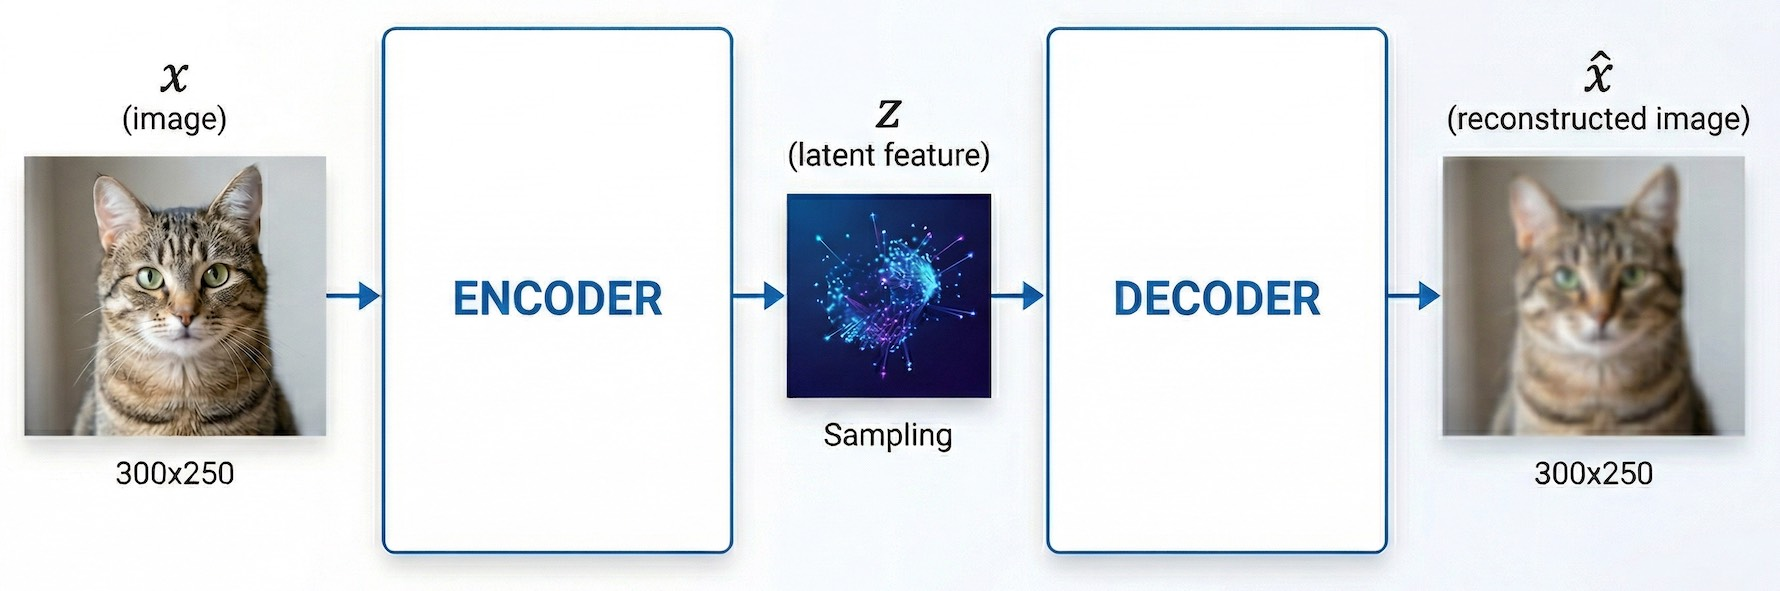

To train the NN-based encoder and decoder, we define the loss function for image reconstructrion. Unlike standard autoencoders that use simple Mean Squared Error (MSE), VAEs are trained by maximizing the Evidence Lower Bound (ELBO), which is equivalent to minimizing the negative ELBO. The loss function consists of two competing terms:
1.  **Reconstruction Loss:** Measures the pixel-wise difference between input $x$ and output $\hat{x}$. We can use MSE (or Binary Cross Entropy) to measure the pixel-wise difference.
2.  **KL Divergence ($D_{KL}$):** Acts as a regularizer. It calculate the distance between the approximated distribution of $z$ (which is a diagonal Gaussian parameterized by the encoder's outputs $\mu$ and $\sigma^2$) and a standard normal distribution $\mathcal{N}(\mathbf{0},\mathbf{I}_d)$.

### Part A: Mathematical Foundation and the Reparameterization Trick (3 Points)
**Questions:**
1. Explain conceptually and algebraically why we cannot use standard back-propagation if we sample $z$ directly as $z\sim\mathcal{N}(\mu, \sigma^2)$ during the training process of a VAE. How does the reparameterization trick $z=\mu+\sigma\odot \epsilon$ solve the problem of using back-propagation? ($\odot$ represents element-wise multiplication and $\epsilon\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)$)
2. Let's look at a simple toy example. Suppose our encoder outputs a scalar $\mu = 2$ and $\sigma = 1$. We sample a value $\epsilon = 0.5$ from the standard normal distribution $\mathcal{N}(0, 1)$. Our loss function is purely a toy reconstruction loss defined as $L = (z - 5)^2$. Use the reparameterization trick to calculate the gradient of the loss with respect to both $\mu$ and $\sigma$.

### Part B: Designing a Convolutional VAE for CIFAR-10 (5 Points)
**Questions:**
Using PyTorch, implement a `ConvVAE` class designed for the CIFAR-10 dataset (where inputs are 3 channels, 32x32 pixels). To avoid dimension mismatch errors, you can use the following specific architecture:

1. **Encoder:** Three `Conv2d` layers with kernel size 3.
    * Layer 1: 3 input channels $\rightarrow$ 16 output channels (with ReLU).
    * Layer 2: 16 input channels $\rightarrow$ 32 output channels (with ReLU).
    * Layer 3: 32 input channels $\rightarrow$ 64 output channels (with ReLU).
    * Apply a ReLU activation after each convolutional layer.
2. **Latent Mapping:** Flatten the output of the final convolutional layer and map it using two separate `Linear` layers to `mu` and `log_var`. The latent space dimension should be parameterized by an initialization variable `latent_dim`.
3. **Reparameterization:** A `reparameterize` method implementing the trick discussed in Part A.
4. **Decoder:** Map the latent vector back to a tensor of shape `(batch_size, 64, 4, 4)` using a `Linear` layer and ReLU. Then use three `ConvTranspose2d` layers to upsample back to 3x32x32.
    * Use kernel size 3 for all three layers.
    * Layer 1: 64 $\rightarrow$ 32 channels (with ReLU).
    * Layer 2: 32 $\rightarrow$ 16 channels (with ReLU).
    * Layer 3: 16 $\rightarrow$ 3 channels.
    * Apply a `Sigmoid` activation to the final output so pixel values are between 0 and 1.
5. **Forward Pass:** A `forward` method seamlessly connecting the encoder, reparameterization, and decoder.

### Part C: The ELBO Loss and Training Loop (7 Points)

**Questions:**
1. Derive the analytical formula for the KL divergence between a univariate Gaussian approximate posterior $q(z|x) = \mathcal{N}(z;\mu,\text{diag}(\sigma^2))$ and a standard normal prior $p(z) = \mathcal{N}(\mathbf{0},\mathbf{I}_d)$. The definition of KL divergence is given by
$$
D_{KL}(q(z|x)\|p(z)) = \int_{\mathcal{Z}}q(z|x)\log\frac{q(z|x)}{p(z)}dz.
$$
Note: For a multi-variate Gaussian distribution, if the dimensions are independent, the total KL divergence is simply the sum of Kl divergence for each dimension.
2. Write a Python function `vae_loss(recon_x, x, mu, log_var)` that computes the negative ELBO (Reconstruction Loss + KL Divergence). Use MSE with `reduction='sum'` for the reconstruction part.
3. Write a Python function `train(model, train_loader, optimizer, epochs)` that trains the model in a training loop for a given number of epochs, and prints out the training loss for each epoch.
4. Write a Python script that execute the training process:
    * **Data Pre-processing:** Ensure you correctly process the image so they are compatible with your decoder's output.
    * **Training:** Train the model for **25 epochs** using learning rate $0.001$. Set the latent space dimension $d=128$. Print the average loss for each epoch.

In [ ]:
def vae_loss(recon_x, x, mu, log_var):
    '''
    This function takes the input image and the reconstructed image, calculates and outputs the loss function for vae.
    Inputs:
        recon_x: reconstructed image from the decoder
        x: original image
        mu: mean of the latent distribution
        log_var: log variance of the latent distribution

    Returns:
        loss: the combined reconstruction and KL divergence loss
    '''
    pass

In [ ]:
def train(model, train_loader, lr, epochs, device):
    '''
    This is a general training function that performs a training loop. For a given model, the function iterates over different epochs and the entire dataset, within each iteration the forward-propagation and backward-propagation are executed.
    Inputs:
        model: the ConvVAE model to be trained
        train_loader: DataLoader for the training dataset
        lr: learning rate
        epochs: number of training epochs
        device: device to run the training on (e.g., 'cuda' or 'cpu')
    '''
    pass

### Part D: Investigating the Compression vs. Performance Trade-off (5 Points)
**Questions:**
The VAE maps high-dimensional CIFAR-10 images (3x32x32 = 3072 dimensions) into a smaller latent representation. The `latent_dim` size controls the "compression rate."
Write a script to investigate how the size of this bottleneck affects the model's ability to reconstruct images.
1. Write a Python function `test()` to evaluate the average reconstruction loss **(only MSE loss)** on the CIFAR-10 **test set**.
2. Instantiate and train three completely separate VAE models using `latent_dim` values of 16, 64, 128, and 256. Train each model for 25 epochs. Use the `test` function to evaluate performance for each trained model. For each trained model, select one image from the test dataset, plot is togehter with its corresponding reconstructed image.
3. Calculate the compression ratio for each latent dimension (the ratio between the size of latent representation $z$ and the input image $x$). Assume an original CIFAR-10 image is 32x32 pixels, 3 channels, where each pixel is an integer value ranging in [0,255]. Assume the latent representation $z$ uses 32-bit floats. Plot the test loss (y-axis) versus the compression ratio (x-axis) using `matplotlib`.
4. Provide a brief discussion on the observed trade-off between the compression rate and reconstruction performance. Why does the loss behave this way?

In [ ]:
def test(model, test_loader, device):
    '''
    Inputs:
        model: the trained ConvVAE model
        test_loader: DataLoader for the test dataset
        device: device to run the testing on (e.g., 'cuda' or 'cpu')

    Returns:
        average_loss: the average loss on the test dataset
    '''
    pass